# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [18]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [19]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Params
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features)) if bias else None

        # Xavier init
        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = x @ self.weight.T
        if self.bias is not None:
            y = y + self.bias
        return y


torch.manual_seed(123)
in_features, out_features = 3, 8
x = torch.randn(2, in_features)

my_model = Linear(in_features, out_features, bias=True)
torch_model = nn.Linear(in_features, out_features, bias=True)

# Copy parameters from custom model to torch model for fair comparison
with torch.no_grad():
    torch_model.weight.copy_(my_model.weight)
    if torch_model.bias is not None:
        torch_model.bias.copy_(my_model.bias)

my_out = my_model(x)
torch_out = torch_model(x)
torch.allclose(my_out, torch_out, atol=1e-6)

True

In [20]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim

        # Params
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))

        # Init
        nn.init.xavier_uniform_(self.weight)

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

my_model = Embedding(10, 128)
torch_model = nn.Embedding(10, 128)

with torch.no_grad():
    torch_model.weight.copy_(my_model.weight)

idx = torch.randint(0, 10, (8, 5))
my_out = my_model(idx)
torch_out = torch_model(idx)
my_out.shape, torch.allclose(my_out, torch_out, atol=1e-6)


(torch.Size([8, 5, 128]), True)

In [21]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if not self.training:
            return x
        
        mask = torch.bernoulli(torch.ones_like(x) * (1 - self.p))
        return x * mask / (1 - self.p)

torch.manual_seed(123)
model = Dropout(0.5)
x = torch.rand(3, 3)
train_out = model(x)
print(train_out)
model.eval()
eval_out = model(x)
print(eval_out)

tensor([[0.0000, 1.0331, 0.0000],
        [1.3771, 0.1479, 1.7330],
        [0.2732, 0.2050, 0.0000]])
tensor([[0.2961, 0.5166, 0.2517],
        [0.6886, 0.0740, 0.8665],
        [0.1366, 0.1025, 0.1841]])


## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [22]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine

        # Params
        if elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))
        else:
            self.weight = None
            self.bias = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, unbiased=False, keepdim=True)
        
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        
        # Scale and shift
        if self.elementwise_affine:
            x_hat = x_hat * self.weight + self.bias
        
        return x_hat

norm = LayerNorm(4, elementwise_affine=False)
x = torch.tensor([[1, 2, 4, 5], [-5, -1, -1, 10]], dtype=torch.float32)
norm(x)

tensor([[-1.2649, -0.6325,  0.6325,  1.2649],
        [-1.0296, -0.3134, -0.3134,  1.6563]])

In [23]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps

        # Params
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        rms = x.pow(2).mean(dim=-1, keepdim=True)
        x_hat = x / torch.sqrt(rms + self.eps)
        x_hat = x_hat * self.weight
        return x_hat

rms = RMSNorm(4)
x = torch.tensor([[1, 2, 4, 5], [-5, -1, -1, 10]], dtype=torch.float32)
rms(x)

tensor([[ 0.2949,  0.5898,  1.1795,  1.4744],
        [-0.8874, -0.1775, -0.1775,  1.7747]], grad_fn=<MulBackward0>)

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [24]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        layers: list[nn.Module] = []

        d_in = in_dim
        for i in range(depth):
            d_out = out_dim if i == depth - 1 else hidden_dim
            
            layers.append(Linear(d_in, d_out))

            if i != depth - 1:
                if use_layernorm:
                    layers.append(LayerNorm(d_out))
                layers.append(nn.GELU())

            d_in = d_out

        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)

In [25]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        
        self.fc1 = Linear(d_model, d_ff)
        self.fc2 = Linear(d_ff, d_model)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

In [26]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [27]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [28]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512, shuffle=False)


In [29]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    B = logits.size(0)
    loss = -torch.nn.functional.log_softmax(logits, dim=-1)
    return loss[torch.arange(B), targets].mean()

torch.manual_seed(123)
logits = torch.randn((4, 10))
targets = torch.randint(0, 10, (4,))
cross_entropy_from_logits(logits, targets)

tensor(2.8022)

In [30]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.mlp = MLP(d_in, 64, num_classes, 4)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.mlp(x)

classifier = ClassificationHead(784, 10)

In [31]:
def accuracy(model: nn.Module, loader: DataLoader):
    model.eval()
    
    correct = 0
    count = 0
    for x, y in loader:
        with torch.no_grad():
            x = x.flatten(start_dim=1)
            logits: torch.Tensor = model(x)
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum()
            count += y.numel()

    acc = correct / count
    return acc.item()

print(f"Pre-Training Accuracy: {accuracy(classifier, test_loader):.4f}")

Pre-Training Accuracy: 0.0838


In [ ]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    torch.manual_seed(seed)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Statistics
    train_loss = []
    test_acc = []

    # Train
    model.train()
    for epoch in range(epochs):
        for x, y in train_data_loader:
            # Forward
            x = x.flatten(start_dim=1)
            logits = model(x)

            # Compute loss
            loss = cross_entropy_from_logits(logits, y)
            train_loss.append(loss.item())

            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Evaluate
        model.eval()
        test_acc.append(accuracy(model, test_data_loader))

        # Print statistics
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss[-1]:.4f} | Test Accuracy: {test_acc[-1]:.4f}")

    return train_loss, test_acc

In [ ]:
# # Train and evaluate classifier
# train_loss, test_acc = train_classifier(classifier, train_loader, test_loader, 0.001, 10)

Epoch 1/10 | Train Loss: 0.3029 | Test Accuracy: 0.9216
Epoch 2/10 | Train Loss: 0.2153 | Test Accuracy: 0.9447
Epoch 3/10 | Train Loss: 0.1643 | Test Accuracy: 0.9538
Epoch 4/10 | Train Loss: 0.2030 | Test Accuracy: 0.9596
Epoch 5/10 | Train Loss: 0.0841 | Test Accuracy: 0.9622
Epoch 6/10 | Train Loss: 0.1600 | Test Accuracy: 0.9657
Epoch 7/10 | Train Loss: 0.0654 | Test Accuracy: 0.9643
Epoch 8/10 | Train Loss: 0.1187 | Test Accuracy: 0.9676
Epoch 9/10 | Train Loss: 0.0704 | Test Accuracy: 0.9722
Epoch 10/10 | Train Loss: 0.0368 | Test Accuracy: 0.9703


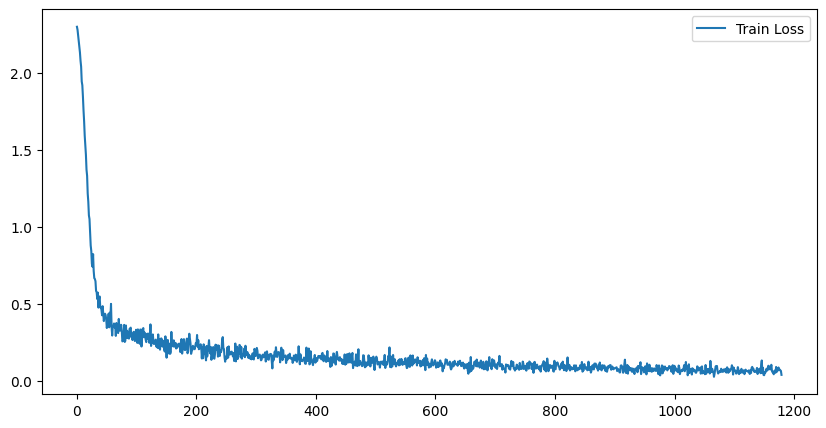

Final Test Accuracy: 0.9703


In [ ]:
# import matplotlib.pyplot as plt

# # Plot train loss curves
# plt.figure(figsize=(10, 5))
# plt.plot(train_loss, label='Train Loss')
# plt.legend()
# plt.show()
# print(f"Final Test Accuracy: {test_acc[-1]:.4f}")